Ячейка 1

In [1]:
from pathlib import Path
import re, html, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack

import pymorphy3, nltk
from nltk.corpus import stopwords

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import StratifiedKFold, HalvingRandomSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, make_scorer

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)

PREP = Path("../data/prepared_datasets")
SEED, N_FOLDS = 42, 3
ACC = make_scorer(accuracy_score)
morph = pymorphy3.MorphAnalyzer()
KEEP = {"не", "нет", "ни", "без", "нельзя"}
STOP = (set(stopwords.words("russian")) | set(stopwords.words("english"))) - KEEP
CYR = re.compile(r"[а-яе]")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


Ячейка 2

In [2]:
TAG = re.compile(r"<[^>]+>")
JUNK = re.compile(r"&(?:quot|amp|lt|gt|nbsp|#\d+);", re.I)
WORD = re.compile(r"[a-zа-яё0-9]+", re.I)

def clean(text: str) -> str:
    s = html.unescape(str(text))
    s = JUNK.sub(" ", s)
    s = TAG.sub(" ", s)
    s = s.lower().replace("ё", "е")
    toks = []
    for w in WORD.findall(s):
        if w.isdigit() or len(w) < 2:
            continue
        if CYR.search(w) and w not in KEEP:
            w = morph.parse(w)[0].normal_form
        if w not in STOP:
            toks.append(w)
    return " ".join(toks)

train = pd.read_csv(PREP / "final_train.csv")
train = train.dropna(subset=["text", "label", "source"]).copy()
train["label"] = train["label"].astype(int)
train["text_clean"] = train["text"].map(clean)
train = train[train["text_clean"].str.len() > 0].reset_index(drop=True)
train["strata"] = train["label"].astype(str) + "|" + train["source"].astype(str)
print(train.shape, train["label"].value_counts().to_dict())
print(train["text_clean"].iloc[0][:160])

(54321, 8) {0: 30728, 1: 23593}
клой кардашьян бо тристан томпсон рубить свой детский бампер nba starend bash


Ячейка 3

In [3]:
folds = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(train, train["strata"]))
print("folds", len(folds))

folds 3


Ячейка 4

In [4]:
def vectorize(tr_text, va_text):
    word = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=120_000, sublinear_tf=True)
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=120_000, sublinear_tf=True)
    Xtr = hstack([word.fit_transform(tr_text), char.fit_transform(tr_text)]).tocsr()
    Xva = hstack([word.transform(va_text), char.transform(va_text)]).tocsr()
    return Xtr, Xva

def scores_of(model, X):
    return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)

def best_threshold(y, score):
    grid = np.quantile(score, np.linspace(0.02, 0.98, 49))
    best_t, best_a = grid[0], -1.0
    for t in grid:
        a = accuracy_score(y, score >= t)
        if a > best_a:
            best_t, best_a = t, a
    return float(best_t)

def plot_threshold(y, score, title):
    grid = np.quantile(score, np.linspace(0.02, 0.98, 50))
    acc, fake, real = [], [], []
    for t in grid:
        pred = (score >= t).astype(int)
        acc.append(accuracy_score(y, pred))
        fake.append(f1_score(y, pred, pos_label=1, zero_division=0))
        real.append(f1_score(y, pred, pos_label=0, zero_division=0))
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(grid, acc, label="accuracy")
    ax.plot(grid, fake, label="F1 fake")
    ax.plot(grid, real, label="F1 real")
    ax.axvline(grid[int(np.argmax(acc))], color="gray", ls="--")
    ax.set_title(title); ax.legend(); plt.tight_layout(); plt.show()

def show_cm(y, pred, title):
    cm = confusion_matrix(y, pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(3.2, 3))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["real", "fake"]); ax.set_yticklabels(["real", "fake"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    ax.set_title(title); plt.tight_layout(); plt.show()

def per_source(df, pred):
    tmp = df.copy(); tmp["pred"] = pred
    rows = []
    for s, g in tmp.groupby("source"):
        rows.append({
            "source": s, "n": len(g), "fake_n": int((g.label == 1).sum()),
            "acc": accuracy_score(g.label, g.pred),
            "f1_fake": f1_score(g.label, g.pred, pos_label=1, zero_division=0),
        })
    return pd.DataFrame(rows).sort_values("acc")

def report(name, y, pred, df):
    print(f"\n=== {name} ===")
    print(f"acc {accuracy_score(y, pred):.3f}  macro {f1_score(y, pred, average='macro'):.3f}  "
          f"f1_fake {f1_score(y, pred, pos_label=1):.3f}")
    print(classification_report(y, pred, digits=3, zero_division=0))
    src = per_source(df, pred)
    print(src.to_string(index=False))
    show_cm(y, pred, name)
    src.plot.barh(x="source", y="acc", legend=False, figsize=(7, 3.4), color="#4C78A8")
    plt.xlim(0, 1); plt.title(f"{name}: accuracy по source"); plt.tight_layout(); plt.show()

Ячейка 5. Линейные, поиск шире

cnb fold 1 acc=0.726 t=0.618 {'alpha': np.float64(0.004961947603002903)}
cnb fold 2 acc=0.727 t=0.608 {'alpha': np.float64(0.0022275429519995563)}
cnb fold 3 acc=0.738 t=0.605 {'alpha': np.float64(0.40615859883769795)}


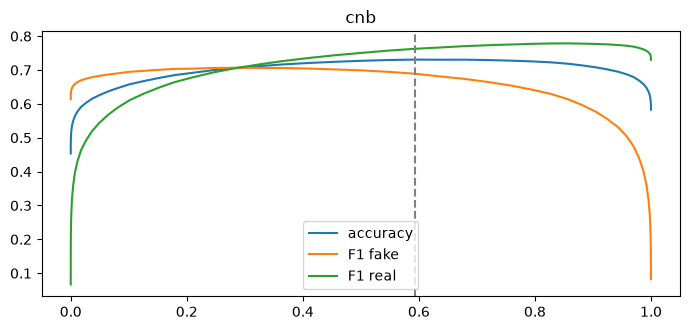


=== cnb ===
acc 0.730  macro 0.725  f1_fake 0.686
              precision    recall  f1-score   support

           0      0.757     0.771     0.764     30728
           1      0.694     0.677     0.686     23593

    accuracy                          0.730     54321
   macro avg      0.726     0.724     0.725     54321
weighted avg      0.730     0.730     0.730     54321

         source     n  fake_n      acc  f1_fake
pubhealth_train  7346    3394 0.624694 0.560357
 pubhealth_test   916     448 0.629913 0.579926
  pubhealth_dev   912     421 0.661184 0.598179
       panorama   655     655 0.667176 0.800366
 onion_huffpost 21845   10508 0.697047 0.681766
      gossipcop  7668    3733 0.718571 0.722408
  train_stances  3475    1745 0.771223 0.775487
   test_stances   868     419 0.775346 0.769776
    danya_train  4550    2270 0.783297 0.777024
         nplus1  6086       0 0.954979 0.000000


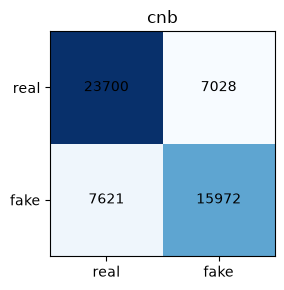

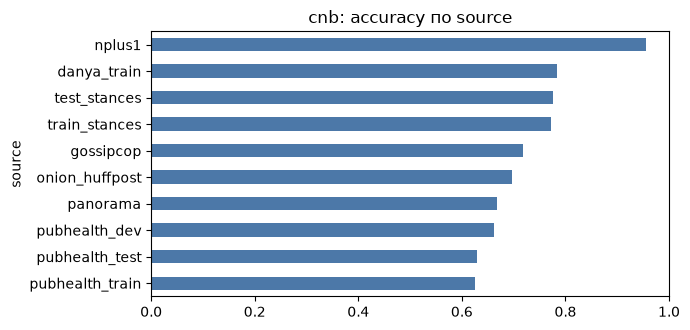

svm fold 1 acc=0.739 t=0.003 {'C': np.float64(0.04961947603002903)}
svm fold 2 acc=0.743 t=0.029 {'C': np.float64(0.04961947603002903)}
svm fold 3 acc=0.744 t=0.030 {'C': np.float64(0.04961947603002903)}


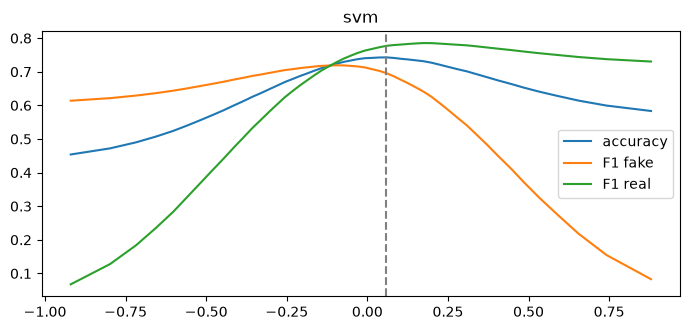


=== svm ===
acc 0.742  macro 0.738  f1_fake 0.707
              precision    recall  f1-score   support

           0      0.778     0.761     0.770     30728
           1      0.698     0.717     0.707     23593

    accuracy                          0.742     54321
   macro avg      0.738     0.739     0.738     54321
weighted avg      0.743     0.742     0.743     54321

         source     n  fake_n      acc  f1_fake
 pubhealth_test   916     448 0.631004 0.615034
pubhealth_train  7346    3394 0.643343 0.617407
       panorama   655     655 0.656489 0.792627
  pubhealth_dev   912     421 0.666667 0.644028
      gossipcop  7668    3733 0.714006 0.714787
 onion_huffpost 21845   10508 0.727352 0.721578
  train_stances  3475    1745 0.745036 0.752514
   test_stances   868     419 0.755760 0.753488
    danya_train  4550    2270 0.783736 0.775547
         nplus1  6086       0 0.952678 0.000000


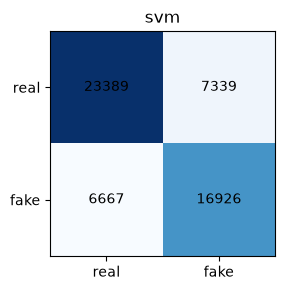

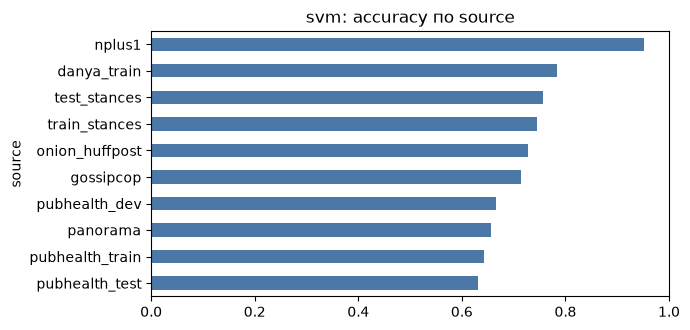

lr fold 1 acc=0.692 t=0.499 {'C': np.float64(0.014924955450518291)}
lr fold 2 acc=0.702 t=0.499 {'C': np.float64(0.014924955450518291)}
lr fold 3 acc=0.722 t=0.507 {'C': np.float64(0.07405684692262435)}


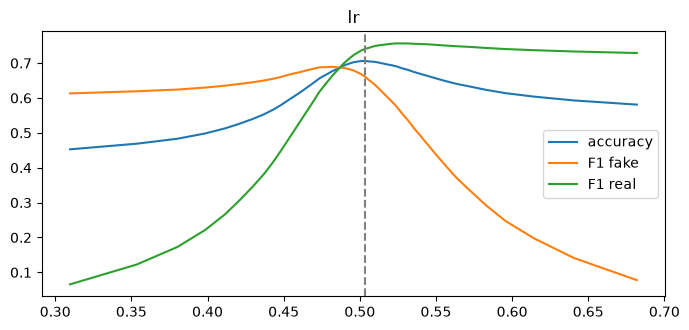


=== lr ===
acc 0.705  macro 0.702  f1_fake 0.669
              precision    recall  f1-score   support

           0      0.749     0.720     0.734     30728
           1      0.653     0.685     0.669     23593

    accuracy                          0.705     54321
   macro avg      0.701     0.703     0.702     54321
weighted avg      0.707     0.705     0.706     54321

         source     n  fake_n      acc  f1_fake
       panorama   655     655 0.554198 0.713163
 pubhealth_test   916     448 0.617904 0.614537
pubhealth_train  7346    3394 0.620201 0.605151
  pubhealth_dev   912     421 0.621711 0.607509
   test_stances   868     419 0.675115 0.662679
 onion_huffpost 21845   10508 0.680751 0.681669
  train_stances  3475    1745 0.682014 0.680728
      gossipcop  7668    3733 0.689619 0.698352
    danya_train  4550    2270 0.732527 0.704253
         nplus1  6086       0 0.954814 0.000000


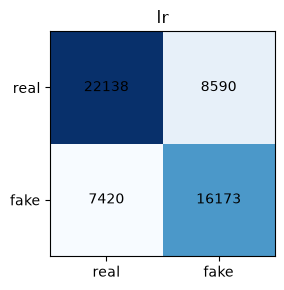

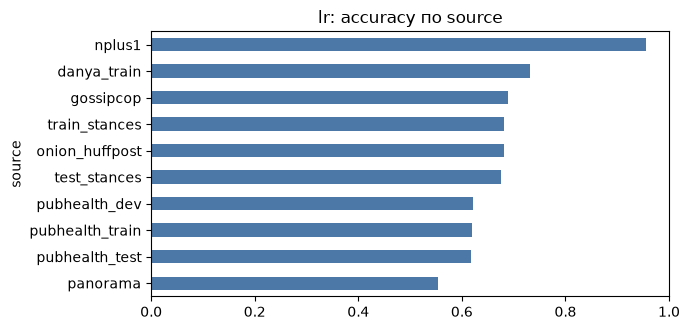

sgd fold 1 acc=0.702 t=1.000 {'alpha': np.float64(2.2275429519995565e-07)}
sgd fold 2 acc=0.736 t=0.523 {'alpha': np.float64(4.0615859883769796e-05)}
sgd fold 3 acc=0.715 t=1.000 {'alpha': np.float64(7.405684692262442e-07)}


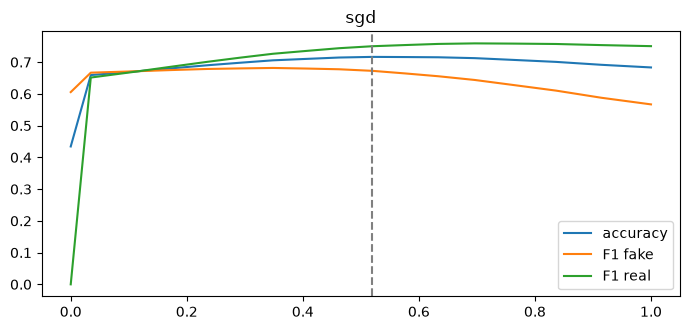


=== sgd ===
acc 0.718  macro 0.711  f1_fake 0.666
              precision    recall  f1-score   support

           0      0.741     0.771     0.756     30728
           1      0.685     0.648     0.666     23593

    accuracy                          0.718     54321
   macro avg      0.713     0.710     0.711     54321
weighted avg      0.716     0.718     0.717     54321

         source     n  fake_n      acc  f1_fake
 pubhealth_test   916     448 0.617904 0.592075
pubhealth_train  7346    3394 0.621699 0.572790
       panorama   655     655 0.630534 0.773408
  pubhealth_dev   912     421 0.671053 0.622166
      gossipcop  7668    3733 0.684403 0.671106
 onion_huffpost 21845   10508 0.697322 0.672738
  train_stances  3475    1745 0.751079 0.751079
   test_stances   868     419 0.759217 0.751486
    danya_train  4550    2270 0.762418 0.751208
         nplus1  6086       0 0.921952 0.000000


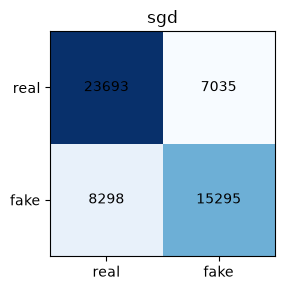

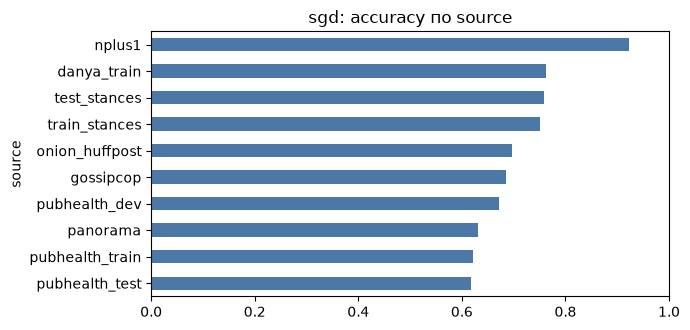

In [5]:
specs = {
    "cnb": (ComplementNB(), {"alpha": np.logspace(-3, 1, 24)}),
    "svm": (LinearSVC(class_weight="balanced", max_iter=8000, random_state=SEED),
            {"C": np.logspace(-2, 2, 24)}),
    "lr": (LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=500, random_state=SEED),
           {"C": np.logspace(-2, 2, 24)}),
    "sgd": (SGDClassifier(loss="modified_huber", class_weight="balanced", max_iter=40, random_state=SEED),
            {"alpha": np.logspace(-7, -3, 24)}),
}
oof_score, oof_pred = {}, {}

for name, (clf, grid) in specs.items():
    oof_score[name] = np.zeros(len(train))
    oof_pred[name] = np.zeros(len(train), dtype=int)
    for i, (tr, va) in enumerate(folds, 1):
        Xtr, Xva = vectorize(train.loc[tr, "text_clean"], train.loc[va, "text_clean"])
        ytr, yva = train.loc[tr, "label"], train.loc[va, "label"]
        search = HalvingRandomSearchCV(
            clf, grid, n_candidates=16, factor=2, cv=3,
            scoring=ACC, random_state=SEED, n_jobs=-1,
        )
        search.fit(Xtr, ytr)
        t = best_threshold(ytr, scores_of(search.best_estimator_, Xtr))
        va_score = scores_of(search.best_estimator_, Xva)
        pred = (va_score >= t).astype(int)
        oof_score[name][va] = va_score
        oof_pred[name][va] = pred
        print(f"{name} fold {i} acc={accuracy_score(yva, pred):.3f} t={t:.3f} {search.best_params_}")
    plot_threshold(train.label, oof_score[name], name)
    report(name, train.label, oof_pred[name], train)

Ячейка 6. CNN

cnn fold 1 acc=0.684 t=0.358
cnn fold 2 acc=0.679 t=0.459
cnn fold 3 acc=0.688 t=0.468


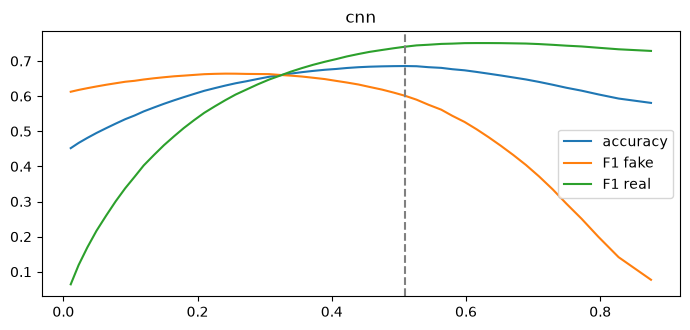


=== cnn ===
acc 0.684  macro 0.678  f1_fake 0.635
              precision    recall  f1-score   support

           0      0.719     0.723     0.721     30728
           1      0.636     0.633     0.635     23593

    accuracy                          0.684     54321
   macro avg      0.678     0.678     0.678     54321
weighted avg      0.683     0.684     0.683     54321

         source     n  fake_n      acc  f1_fake
       panorama   655     655 0.558779 0.716944
 pubhealth_test   916     448 0.586245 0.570781
pubhealth_train  7346    3394 0.606725 0.579904
  pubhealth_dev   912     421 0.626096 0.589651
 onion_huffpost 21845   10508 0.654612 0.631682
      gossipcop  7668    3733 0.663015 0.669903
  train_stances  3475    1745 0.687482 0.686851
   test_stances   868     419 0.688940 0.678571
    danya_train  4550    2270 0.715385 0.699047
         nplus1  6086       0 0.915872 0.000000


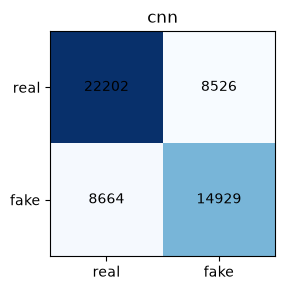

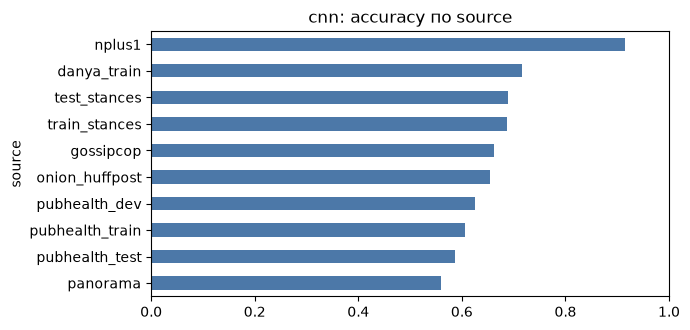

In [6]:
MAX_WORDS, MAX_LEN, EPOCHS, BATCH = 40_000, 48, 12, 256

def encode(texts, vocab):
    rows = []
    for t in texts:
        ids = [vocab.get(w, 1) for w in str(t).split()][:MAX_LEN]
        rows.append(ids + [0] * (MAX_LEN - len(ids)))
    return np.asarray(rows, dtype=np.int64)

class TextCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.emb = nn.Embedding(n, 96, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(96, 96, k) for k in (2, 3, 4)])
        self.fc = nn.Sequential(nn.Linear(288, 96), nn.ReLU(), nn.Dropout(0.3), nn.Linear(96, 1))
    def forward(self, x):
        h = self.emb(x).transpose(1, 2)
        h = torch.cat([torch.relu(c(h)).max(2).values for c in self.convs], 1)
        return self.fc(h).squeeze(1)

cnn_score, cnn_pred = np.zeros(len(train)), np.zeros(len(train), dtype=int)
for i, (tr, va) in enumerate(folds, 1):
    counts = {}
    for t in train.loc[tr, "text_clean"]:
        for w in t.split():
            counts[w] = counts.get(w, 0) + 1
    vocab = {"<pad>": 0, "<unk>": 1}
    for w, _ in sorted(counts.items(), key=lambda kv: -kv[1])[:MAX_WORDS - 2]:
        vocab[w] = len(vocab)
    Xtr = torch.tensor(encode(train.loc[tr, "text_clean"], vocab))
    Xva = torch.tensor(encode(train.loc[va, "text_clean"], vocab))
    ytr = torch.tensor(train.loc[tr, "label"].values, dtype=torch.float32)
    yva = train.loc[va, "label"].values
    loader = DataLoader(TensorDataset(Xtr, ytr), BATCH, shuffle=True)
    model = TextCNN(len(vocab)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    best, wait, state = -1.0, 0, None
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pr = torch.sigmoid(model(Xva.to(DEVICE))).cpu().numpy()
        acc = accuracy_score(yva, pr >= 0.5)
        if acc > best:
            best, wait = acc, 0
            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= 3:
                break
    model.load_state_dict(state); model.eval()
    with torch.no_grad():
        tr_score = torch.sigmoid(model(Xtr.to(DEVICE))).cpu().numpy()
        va_score = torch.sigmoid(model(Xva.to(DEVICE))).cpu().numpy()
    t = best_threshold(train.loc[tr, "label"], tr_score)
    cnn_score[va] = va_score
    cnn_pred[va] = (va_score >= t).astype(int)
    print(f"cnn fold {i} acc={accuracy_score(yva, cnn_pred[va]):.3f} t={t:.3f}")

plot_threshold(train.label, cnn_score, "cnn")
report("cnn", train.label, cnn_pred, train)
oof_score["cnn"], oof_pred["cnn"] = cnn_score, cnn_pred

Ячейка 7. Ансамбль

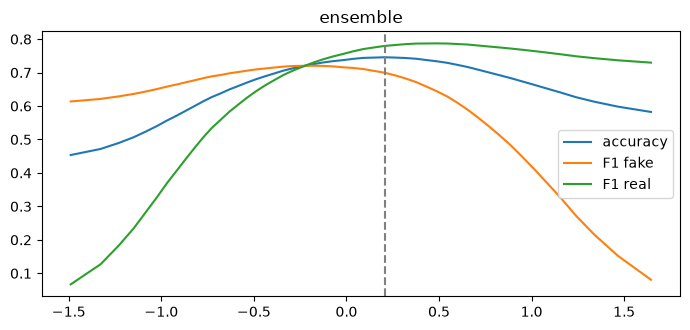


=== ensemble ===
acc 0.746  macro 0.740  f1_fake 0.701
              precision    recall  f1-score   support

           0      0.766     0.793     0.779     30728
           1      0.718     0.684     0.701     23593

    accuracy                          0.746     54321
   macro avg      0.742     0.739     0.740     54321
weighted avg      0.745     0.746     0.745     54321

         source     n  fake_n      acc  f1_fake
 pubhealth_test   916     448 0.636463 0.603099
       panorama   655     655 0.636641 0.777985
pubhealth_train  7346    3394 0.642390 0.596281
  pubhealth_dev   912     421 0.678728 0.629583
 onion_huffpost 21845   10508 0.723735 0.705222
      gossipcop  7668    3733 0.724700 0.721614
  train_stances  3475    1745 0.767770 0.768569
   test_stances   868     419 0.769585 0.762470
    danya_train  4550    2270 0.792308 0.779360
         nplus1  6086       0 0.965166 0.000000


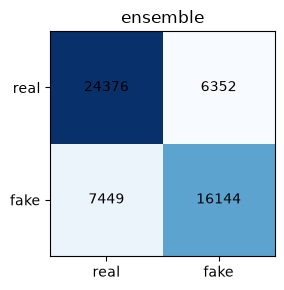

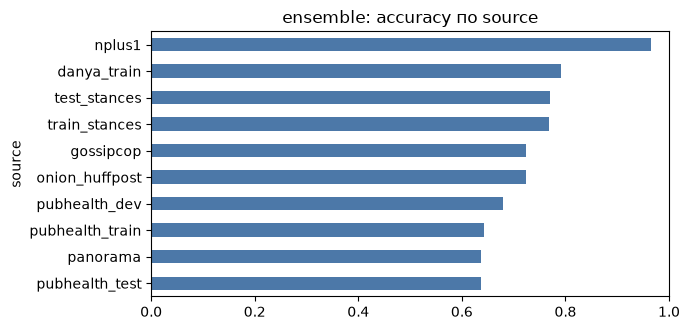

In [7]:
names = ["cnb", "svm", "lr", "sgd", "cnn"]
z = [(oof_score[n] - oof_score[n].mean()) / (oof_score[n].std() + 1e-9) for n in names]
ens = np.mean(z, axis=0)
ens_pred = np.zeros(len(train), dtype=int)
for tr, va in folds:
    t = best_threshold(train.loc[tr, "label"], ens[tr])
    ens_pred[va] = (ens[va] >= t).astype(int)
plot_threshold(train.label, ens, "ensemble")
report("ensemble", train.label, ens_pred, train)
oof_pred["ensemble"] = ens_pred

Ячейка 8

   model      acc  macro_f1  f1_fake  f1_real
ensemble 0.745936  0.739964 0.700558 0.779371
     svm 0.742162  0.738460 0.707343 0.769578
     cnb 0.730325  0.724754 0.685597 0.763912
     sgd 0.717733  0.710822 0.666115 0.755529
      lr 0.705271  0.701673 0.668914 0.734433
     cnn 0.683548  0.677771 0.634628 0.720914


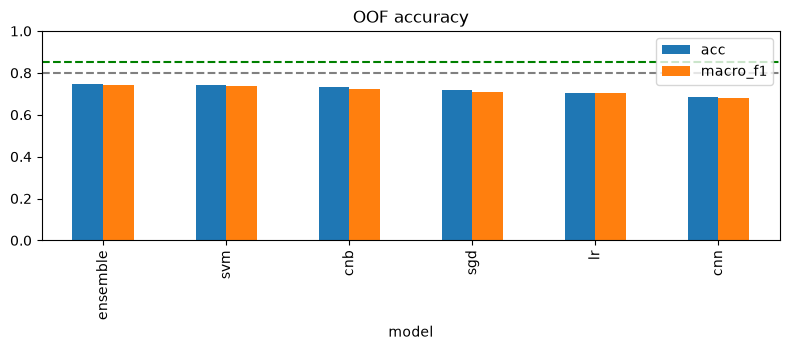

In [8]:
rows = []
for name, pred in oof_pred.items():
    rows.append({
        "model": name,
        "acc": accuracy_score(train.label, pred),
        "macro_f1": f1_score(train.label, pred, average="macro"),
        "f1_fake": f1_score(train.label, pred, pos_label=1),
        "f1_real": f1_score(train.label, pred, pos_label=0),
    })
summary = pd.DataFrame(rows).sort_values("acc", ascending=False)
print(summary.to_string(index=False))
summary.set_index("model")[["acc", "macro_f1"]].plot.bar(figsize=(8, 3.6))
plt.ylim(0, 1); plt.axhline(0.80, color="gray", ls="--"); plt.axhline(0.85, color="green", ls="--")
plt.title("OOF accuracy"); plt.tight_layout(); plt.show()